# Student Performance Prediction
## A Statistical Analysis Project using Python

**Tools Used:** Pandas, Matplotlib, Seaborn, SciPy

**Dataset:** 200 Students | 6 Columns

**Goal:** Understand student performance through basic statistics

---
## Setup: Import Libraries

In [79]:
# Import all required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import math

# Make plots look clean
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120
print("All libraries imported successfully!")

All libraries imported successfully!


---
## Generate Dataset
We create a realistic dataset of 200 students with correlated scores.

In [80]:
import pandas as pd
df = pd.read_csv("students_performance.csv")
score_cols = ["MathScore", "ReadingScore", "WritingScore"]
print(f"Dataset loaded: {len(df)} students, {len(df.columns)} columns")
df.head()

Dataset loaded: 200 students, 6 columns


---
# SECTION 1: Basic Analysis (5 Marks)

### Step 1: View First 5 Rows

In [81]:
df.head()

,Gender,Lunch,TestPreparationCourse,MathScore,ReadingScore,WritingScore
0,Female,free/reduced,none,75,64,79
1,Male,free/reduced,completed,72,70,62
2,Male,free/reduced,none,83,77,82
3,Male,standard,none,100,95,100
4,Female,standard,none,55,65,68


### Step 2: Check Missing Values

In [82]:
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

Gender                   0
Lunch                    0
TestPreparationCourse    0
MathScore                0
ReadingScore             0
WritingScore             0
dtype: int64

Total missing values: 0


### Step 3: Basic Descriptive Statistics
- **Mean** = Average score
- **Median** = Middle value when sorted
- **Std Dev** = How spread out the scores are

In [83]:
score_cols = ["MathScore", "ReadingScore", "WritingScore"]

for col in score_cols:
    print(f"\n{col}:")
    print(f"  Mean (Average)        = {df[col].mean():.2f}")
    print(f"  Median (Middle value) = {df[col].median():.2f}")
    print(f"  Std Dev (Spread)      = {df[col].std():.2f}")
    print(f"  Min                   = {df[col].min()}")
    print(f"  Max                   = {df[col].max()}")


MathScore:
  Mean (Average)        = 68.81
  Median (Middle value) = 70.00
  Std Dev (Spread)      = 16.35
  Min                   = 21
  Max                   = 100

ReadingScore:
  Mean (Average)        = 70.84
  Median (Middle value) = 70.50
  Std Dev (Spread)      = 14.81
  Min                   = 33
  Max                   = 100

WritingScore:
  Mean (Average)        = 70.20
  Median (Middle value) = 71.00
  Std Dev (Spread)      = 15.64
  Min                   = 22
  Max                   = 100


### Step 4a: Histogram of Scores

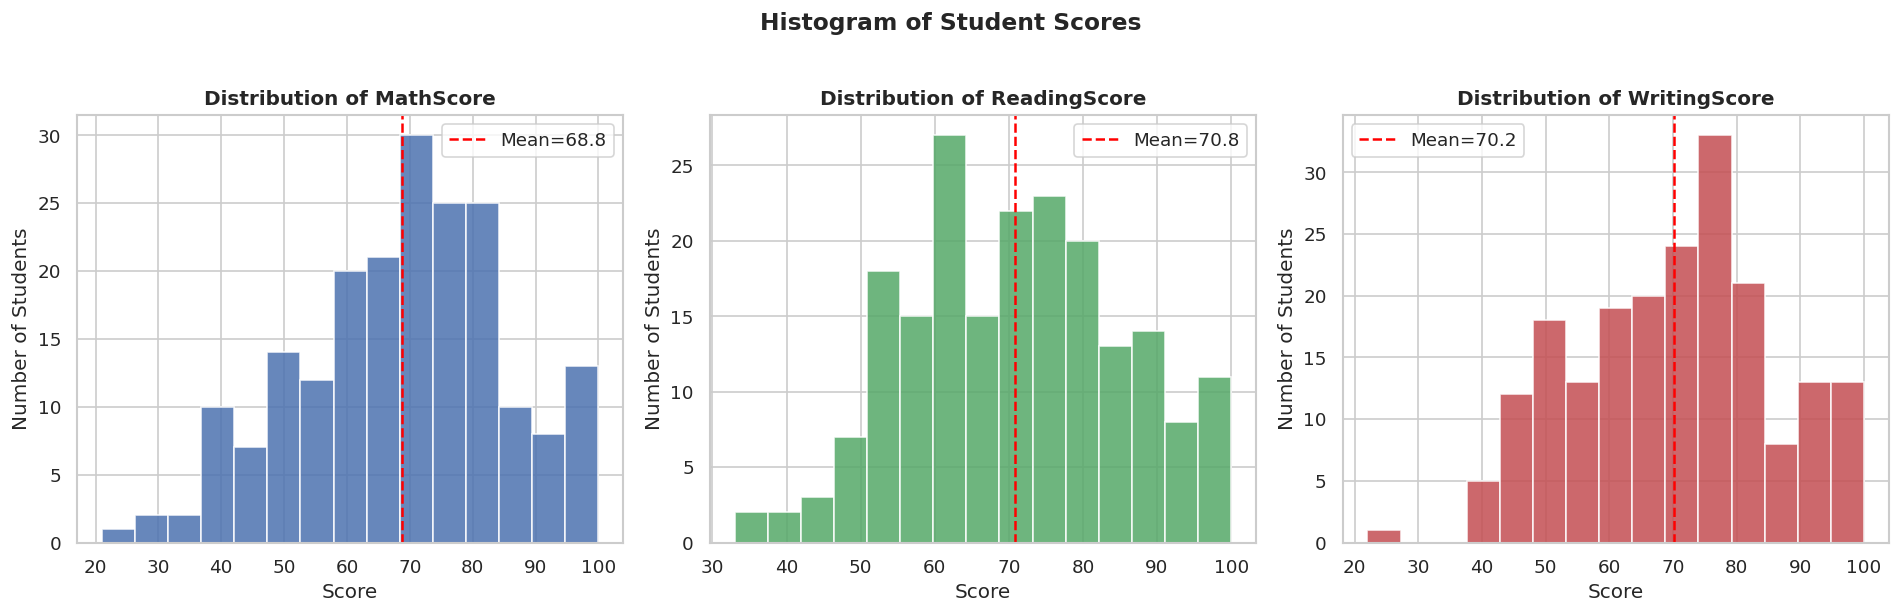

In [84]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ["#4C72B0", "#55A868", "#C44E52"]

for i, col in enumerate(score_cols):
    axes[i].hist(df[col], bins=15, color=colors[i], edgecolor="white", alpha=0.85)
    axes[i].set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Score")
    axes[i].set_ylabel("Number of Students")
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", linewidth=1.5, label=f"Mean={df[col].mean():.1f}")
    axes[i].legend()

plt.suptitle("Histogram of Student Scores", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Step 4b: Boxplot
The box = middle 50% of students. Red line = median. Dots outside = outliers.

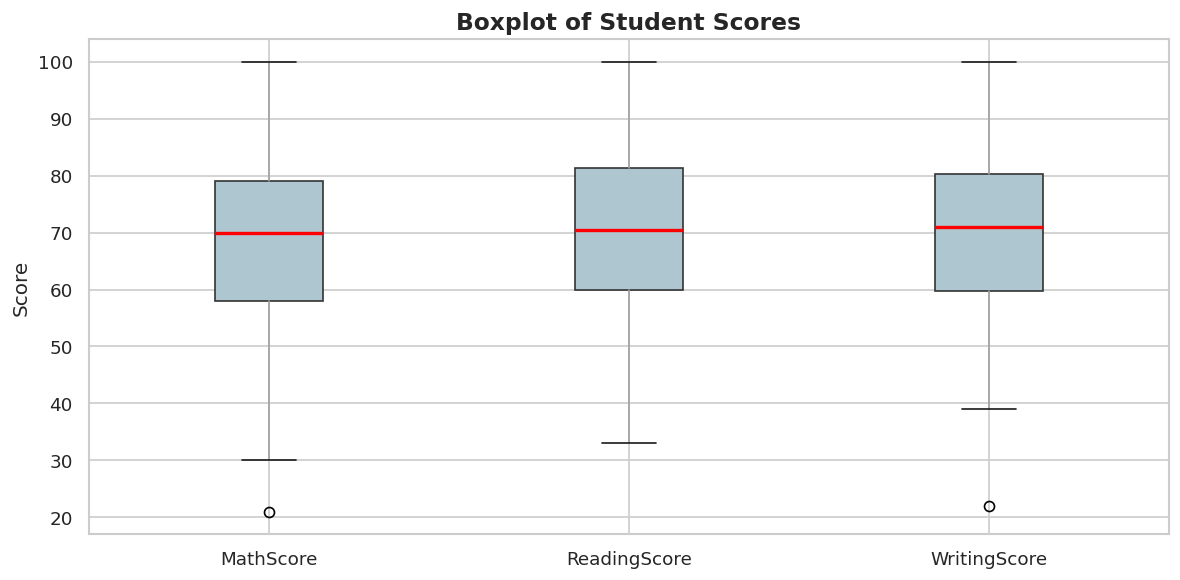

In [85]:
fig, ax = plt.subplots(figsize=(10, 5))
df[score_cols].boxplot(ax=ax, patch_artist=True,
    boxprops=dict(facecolor="#AEC6CF", color="#333"),
    medianprops=dict(color="red", linewidth=2))
ax.set_title("Boxplot of Student Scores", fontsize=14, fontweight="bold")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()

### Step 4c: Scatter Plot (Math vs Reading)

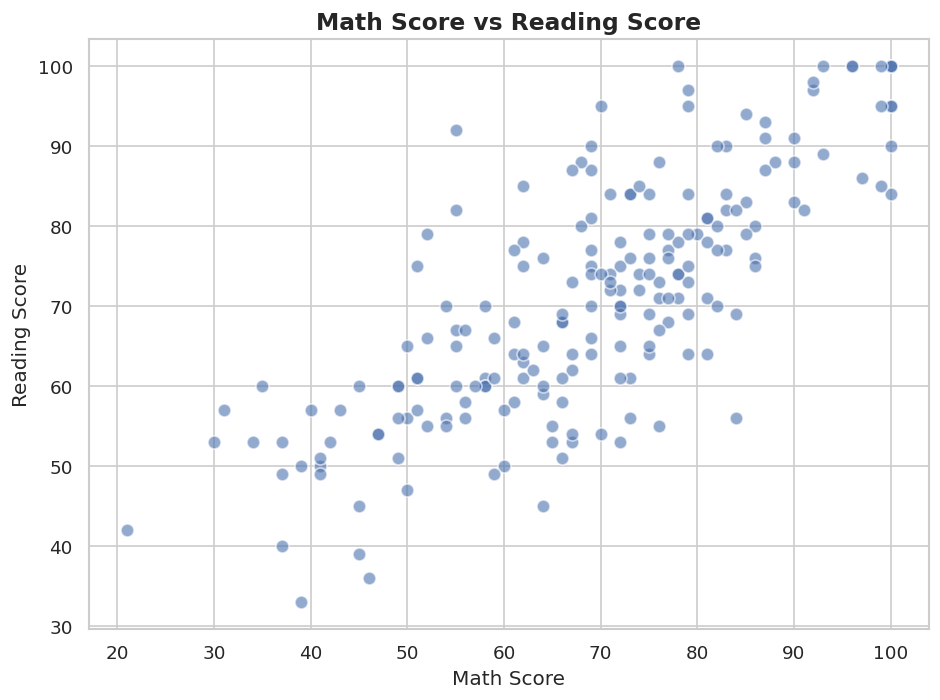

In [86]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["MathScore"], df["ReadingScore"], alpha=0.6, color="#4C72B0", edgecolors="white", s=60)
ax.set_title("Math Score vs Reading Score", fontsize=14, fontweight="bold")
ax.set_xlabel("Math Score")
ax.set_ylabel("Reading Score")
plt.tight_layout()
plt.show()

---
# SECTION 2: Probability, Bayes' Theorem & CLT (5 Marks)

### Step 1: Probability of High Academic Achievement
**Probability** = (students with good score) / (total students)

In [87]:
GOOD_SCORE_THRESHOLD = 70
print(f"Good Score Threshold = {GOOD_SCORE_THRESHOLD}\n")

for col in score_cols:
    good_count = (df[col] > GOOD_SCORE_THRESHOLD).sum()
    total = len(df)
    probability = good_count / total
    print(f"{col}: {good_count}/{total} students scored above {GOOD_SCORE_THRESHOLD} => P = {probability:.4f} ({probability:.2%})")

Good Score Threshold = 70

MathScore: 99/200 students scored above 70 => P = 0.4950 (49.50%)
ReadingScore: 100/200 students scored above 70 => P = 0.5000 (50.00%)
WritingScore: 102/200 students scored above 70 => P = 0.5100 (51.00%)


### Step 2: Bayes' Theorem Application

**Question:** Given that a student scored high in Math (>70), what is the probability that they ALSO completed test preparation?

**Formula:**
$$P(Prep | HighMath) = \frac{P(HighMath | Prep) \times P(Prep)}{P(HighMath)}$$

Where:
- **P(Prep)** = Prior probability of having done test prep
- **P(HighMath | Prep)** = Likelihood of high math given test prep was done
- **P(HighMath)** = Overall probability of getting high math score
- **P(Prep | HighMath)** = Posterior: probability of test prep given high math score

In [88]:
# ─── BAYES' THEOREM ─────────────────────────────────────────
# Question: P(TestPrep=completed | MathScore > 70) = ?

total = len(df)

# Prior: P(Prep)
prep_done = df[df["TestPreparationCourse"] == "completed"]
P_prep = len(prep_done) / total

# Likelihood: P(HighMath | Prep)
high_math_given_prep = (prep_done["MathScore"] > 70).sum() / len(prep_done)
P_highmath_given_prep = high_math_given_prep

# Evidence: P(HighMath)  — total students with Math > 70
P_highmath = (df["MathScore"] > 70).sum() / total

# ─── Apply Bayes' Theorem ───────────────────────────────────
P_prep_given_highmath = (P_highmath_given_prep * P_prep) / P_highmath

print("=" * 55)
print("  BAYES' THEOREM: P(TestPrep | HighMath > 70)")
print("=" * 55)
print(f"  P(TestPrep completed)          = {P_prep:.4f}  ({P_prep:.2%})")
print(f"  P(MathScore>70 | TestPrep done)= {P_highmath_given_prep:.4f}  ({P_highmath_given_prep:.2%})")
print(f"  P(MathScore>70)  [evidence]    = {P_highmath:.4f}  ({P_highmath:.2%})")
print(f"  ─────────────────────────────────────────────────────")
print(f"  P(TestPrep done | MathScore>70)= {P_prep_given_highmath:.4f}  ({P_prep_given_highmath:.2%})")
print()
print("  INTERPRETATION:")
print(f"  If a student scored above 70 in Math, there is a")
print(f"  {P_prep_given_highmath:.2%} probability they completed test preparation.")
print(f"  Compared to prior probability of {P_prep:.2%},")
diff = P_prep_given_highmath - P_prep
print(f"  test prep increases the chance of high math by {diff*100:.1f} percentage points.")

  BAYES' THEOREM: P(TestPrep | HighMath > 70)
  P(TestPrep completed)          = 0.3550  (35.50%)
  P(MathScore>70 | TestPrep done)= 0.5634  (56.34%)
  P(MathScore>70)  [evidence]    = 0.4950  (49.50%)
  ─────────────────────────────────────────────────────
  P(TestPrep done | MathScore>70)= 0.4040  (40.40%)

  INTERPRETATION:
  If a student scored above 70 in Math, there is a
  40.40% probability they completed test preparation.
  Compared to prior probability of 35.50%,
  test prep increases the chance of high math by 4.9 percentage points.


### Step 3: Central Limit Theorem (CLT) Analysis

**The CLT says:** No matter what shape a population distribution has, if we take many random samples of size n, the **distribution of sample means** will approach a normal (bell) curve.

**We will verify this** by:
1. Taking 1000 random samples of size n=30 from MathScore
2. Computing the mean of each sample
3. Plotting those 1000 means — they should look like a bell curve!

  CENTRAL LIMIT THEOREM - Math Score
  Population Mean (μ)        = 68.81
  Population Std Dev (σ)     = 16.35
  Sample Size (n)            = 30
  Number of Samples          = 1000

  ── CLT Predictions ──────────────────────────────
  Theoretical Mean of Means  = 68.81
  Theoretical Std Error (σ/√n) = 2.9842

  ── Observed from Simulation ─────────────────────
  Observed Mean of Means     = 68.71  (should ≈ 68.81)
  Observed Std of Means      = 2.8769  (should ≈ 2.9842)

  The values match closely — CLT is verified! ✓


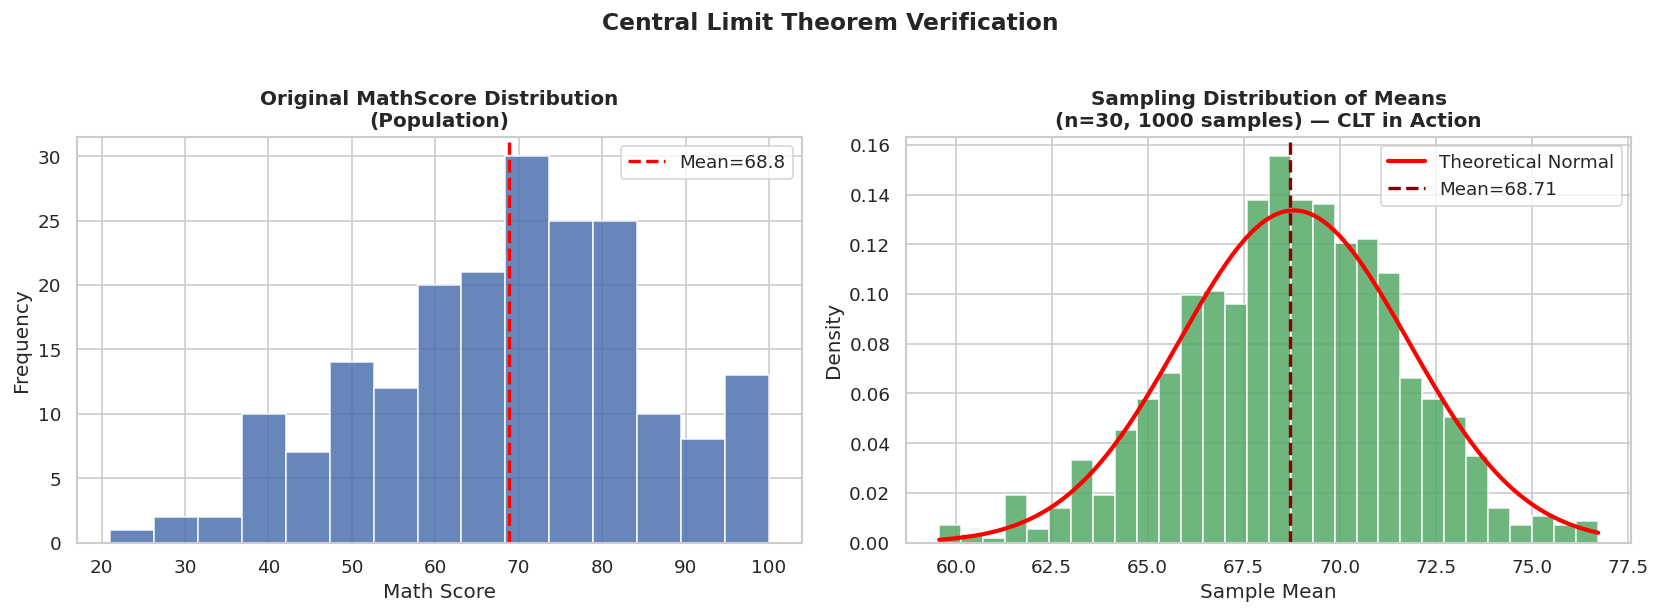


CONCLUSION: Even though the original distribution may not be perfectly normal,
the distribution of SAMPLE MEANS (right chart) is approximately bell-shaped.
This confirms the Central Limit Theorem.


In [89]:
# ─── CENTRAL LIMIT THEOREM DEMONSTRATION ────────────────────

np.random.seed(42)

sample_size = 30       # Each sample has 30 students
num_samples = 1000     # We take 1000 samples

# Collect the mean of each sample
sample_means = []
for _ in range(num_samples):
    sample = df["MathScore"].sample(n=sample_size, replace=True)
    sample_means.append(sample.mean())

sample_means = np.array(sample_means)

# ─── Theoretical values (CLT prediction) ────────────────────
pop_mean = df["MathScore"].mean()
pop_std  = df["MathScore"].std()
theoretical_se = pop_std / np.sqrt(sample_size)   # Standard Error

print("=" * 55)
print("  CENTRAL LIMIT THEOREM - Math Score")
print("=" * 55)
print(f"  Population Mean (μ)        = {pop_mean:.2f}")
print(f"  Population Std Dev (σ)     = {pop_std:.2f}")
print(f"  Sample Size (n)            = {sample_size}")
print(f"  Number of Samples          = {num_samples}")
print(f"")
print(f"  ── CLT Predictions ──────────────────────────────")
print(f"  Theoretical Mean of Means  = {pop_mean:.2f}")
print(f"  Theoretical Std Error (σ/√n) = {theoretical_se:.4f}")
print(f"")
print(f"  ── Observed from Simulation ─────────────────────")
print(f"  Observed Mean of Means     = {sample_means.mean():.2f}  (should ≈ {pop_mean:.2f})")
print(f"  Observed Std of Means      = {sample_means.std():.4f}  (should ≈ {theoretical_se:.4f})")
print()
print("  The values match closely — CLT is verified! ✓")

# ─── Plot: Original distribution vs sampling distribution ────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Original skewed/raw distribution
axes[0].hist(df["MathScore"], bins=15, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].axvline(pop_mean, color="red", linestyle="--", linewidth=2, label=f"Mean={pop_mean:.1f}")
axes[0].set_title("Original MathScore Distribution\n(Population)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Math Score")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Right: Sampling distribution of means (should be bell-shaped)
axes[1].hist(sample_means, bins=30, color="#55A868", edgecolor="white", alpha=0.85, density=True)
# Overlay the theoretical normal curve
x = np.linspace(sample_means.min(), sample_means.max(), 200)
y = stats.norm.pdf(x, pop_mean, theoretical_se)
axes[1].plot(x, y, color="red", linewidth=2.5, label="Theoretical Normal")
axes[1].axvline(sample_means.mean(), color="darkred", linestyle="--", linewidth=2, label=f"Mean={sample_means.mean():.2f}")
axes[1].set_title(f"Sampling Distribution of Means\n(n=30, 1000 samples) — CLT in Action", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Sample Mean")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.suptitle("Central Limit Theorem Verification", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nCONCLUSION: Even though the original distribution may not be perfectly normal,")
print("the distribution of SAMPLE MEANS (right chart) is approximately bell-shaped.")
print("This confirms the Central Limit Theorem.")

---
# SECTION 3: Confidence Interval & Hypothesis Testing (5 Marks)

### Step 0: Normality Check (Shapiro-Wilk Test)

Before applying the t-test and confidence interval, we verify that MathScore is approximately normally distributed.

- **H₀:** Data is normally distributed
- If p-value > 0.05 → data is normal → t-test is valid

Shapiro-Wilk p-value: 0.05908712858605156


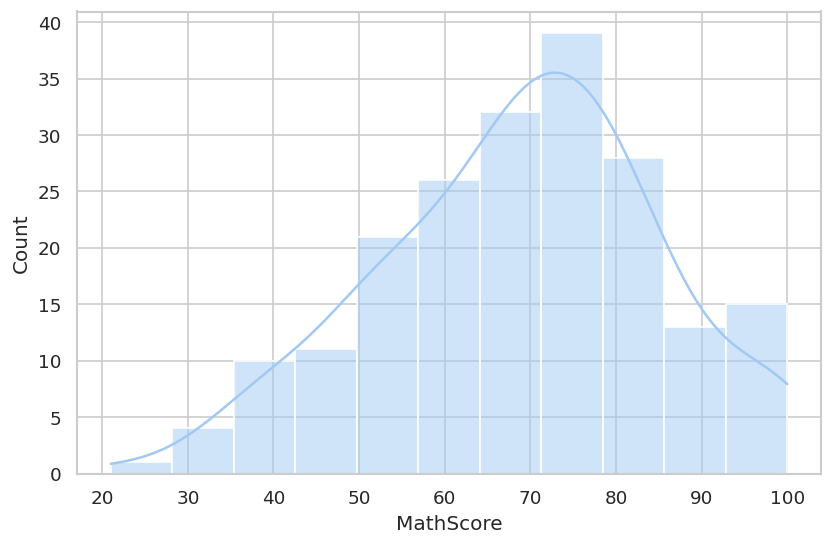

In [90]:
from scipy.stats import shapiro

# Plot distribution with KDE curve
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["MathScore"], kde=True, color="#4C72B0", ax=ax)
ax.set_title("MathScore Distribution with KDE", fontsize=13, fontweight="bold")
ax.set_xlabel("Math Score")
plt.tight_layout()
plt.show()

# Shapiro-Wilk normality test
stat, p = shapiro(df["MathScore"])
print(f"Shapiro-Wilk Statistic = {stat:.4f}")
print(f"p-value                = {p:.4f}")
if p > 0.05:
    print("Result: p > 0.05 → Data is approximately NORMAL → t-test is valid ✓")
else:
    print("Result: p <= 0.05 → Data is NOT perfectly normal (but CLT covers us for n=200)")

### Step 1: Confidence Interval for Math Scores

A **95% Confidence Interval** means: *"We are 95% confident the true population mean falls within this range."*

**Formula:**
$$CI = \bar{x} \pm z_{\alpha/2} \times \frac{\sigma}{\sqrt{n}}$$

Where z = 1.96 for 95% confidence.

In [91]:
# ─── CONFIDENCE INTERVAL FOR MATH SCORES ────────────────────

n = len(df)
x_bar = df["MathScore"].mean()     # Sample mean
s     = df["MathScore"].std()      # Sample std deviation
se    = s / np.sqrt(n)             # Standard Error

# 95% CI using t-distribution (better for real data)
confidence_level = 0.95
alpha = 1 - confidence_level
t_critical = stats.t.ppf(1 - alpha/2, df=n-1)   # t critical value

margin_of_error = t_critical * se
ci_lower = x_bar - margin_of_error
ci_upper = x_bar + margin_of_error

print("=" * 55)
print("  CONFIDENCE INTERVAL FOR MATH SCORES")
print("=" * 55)
print(f"  Sample Size (n)        = {n}")
print(f"  Sample Mean (x̄)       = {x_bar:.2f}")
print(f"  Sample Std Dev (s)     = {s:.2f}")
print(f"  Standard Error (s/√n)  = {se:.4f}")
print(f"  t-critical (95%, df={n-1}) = {t_critical:.4f}")
print(f"  Margin of Error        = ± {margin_of_error:.4f}")
print()
print(f"  95% Confidence Interval:")
print(f"  [{ci_lower:.2f}, {ci_upper:.2f}]")
print()
print(f"  INTERPRETATION:")
print(f"  We are 95% confident that the true average Math")
print(f"  score of all students lies between {ci_lower:.2f} and {ci_upper:.2f}.")

# Also compute for all 3 subjects
print()
print(f"  {'Subject':<15} {'Mean':>8} {'95% CI Lower':>14} {'95% CI Upper':>14}")
print(f"  {'-'*55}")
for col in score_cols:
    m = df[col].mean()
    s2 = df[col].std()
    se2 = s2 / np.sqrt(n)
    moe = t_critical * se2
    print(f"  {col:<15} {m:>8.2f} {m-moe:>14.2f} {m+moe:>14.2f}")

  CONFIDENCE INTERVAL FOR MATH SCORES
  Sample Size (n)        = 200
  Sample Mean (x̄)       = 68.81
  Sample Std Dev (s)     = 16.35
  Standard Error (s/√n)  = 1.1558
  t-critical (95%, df=199) = 1.9720
  Margin of Error        = ± 2.2791

  95% Confidence Interval:
  [66.53, 71.08]

  INTERPRETATION:
  We are 95% confident that the true average Math
  score of all students lies between 66.53 and 71.08.

  Subject             Mean   95% CI Lower   95% CI Upper
  -------------------------------------------------------
  MathScore          68.81          66.53          71.08
  ReadingScore       70.84          68.78          72.91
  WritingScore       70.20          68.02          72.39


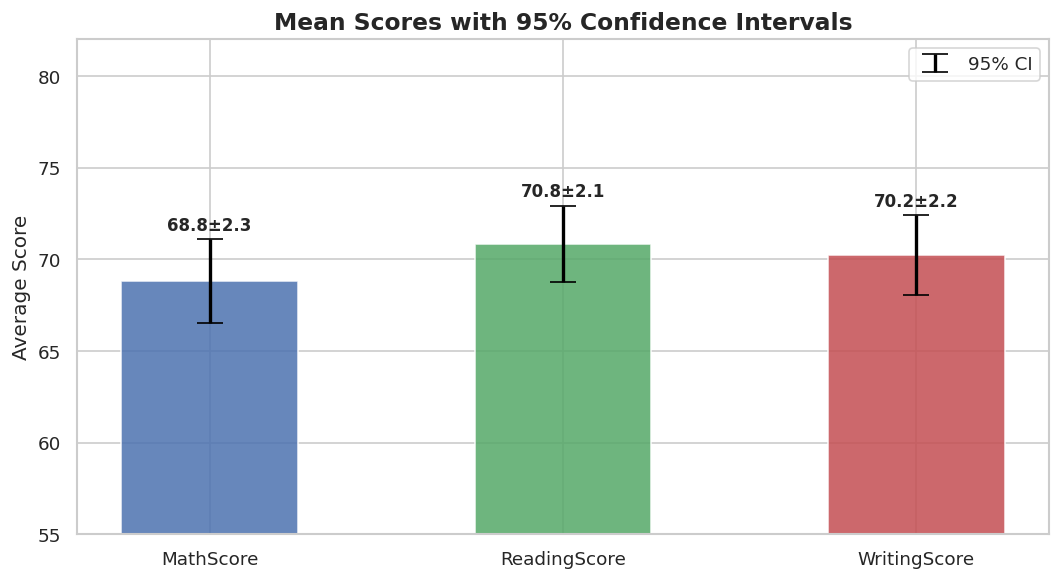

In [92]:
# ─── Visualize the Confidence Interval ──────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

means = [df[col].mean() for col in score_cols]
cis   = []
for col in score_cols:
    m = df[col].mean()
    se2 = df[col].std() / np.sqrt(len(df))
    moe = t_critical * se2
    cis.append(moe)

x_pos = np.arange(len(score_cols))
ax.bar(x_pos, means, color=["#4C72B0","#55A868","#C44E52"], edgecolor="white", alpha=0.85, width=0.5)
ax.errorbar(x_pos, means, yerr=cis, fmt='none', color='black', capsize=8, linewidth=2, label="95% CI")

ax.set_xticks(x_pos)
ax.set_xticklabels(score_cols)
ax.set_ylabel("Average Score")
ax.set_title("Mean Scores with 95% Confidence Intervals", fontsize=14, fontweight="bold")
ax.set_ylim(55, 82)
ax.legend(fontsize=11)

for i, (m, ci) in enumerate(zip(means, cis)):
    ax.text(i, m + ci + 0.5, f"{m:.1f}±{ci:.1f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Step 2: Hypothesis Testing — Gender-Based Performance

- **H₀:** No difference between male and female Math scores
- **H₁:** There IS a difference
- **α = 0.05**

In [93]:
male_math   = df[df["Gender"] == "Male"]["MathScore"]
female_math = df[df["Gender"] == "Female"]["MathScore"]

print(f"Male students  : {len(male_math)} (Avg Math = {male_math.mean():.2f})")
print(f"Female students: {len(female_math)} (Avg Math = {female_math.mean():.2f})")

t_stat, p_value = stats.ttest_ind(male_math, female_math)

print(f"\nT-Test Results:")
print(f"  t-statistic = {t_stat:.4f}")
print(f"  p-value     = {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"\n  RESULT: p-value ({p_value:.4f}) < {alpha} → REJECT H₀")
    print("  There IS a significant difference!")
else:
    print(f"\n  RESULT: p-value ({p_value:.4f}) >= {alpha} → FAIL TO REJECT H₀")
    print("  There is NO significant difference.")
    print("  Male and female students perform similarly in Math.")

Male students  : 102 (Avg Math = 69.98)
Female students: 98 (Avg Math = 67.58)

T-Test Results:
  t-statistic = 1.0377
  p-value     = 0.3007

  RESULT: p-value (0.3007) >= 0.05 → FAIL TO REJECT H₀
  There is NO significant difference.
  Male and female students perform similarly in Math.


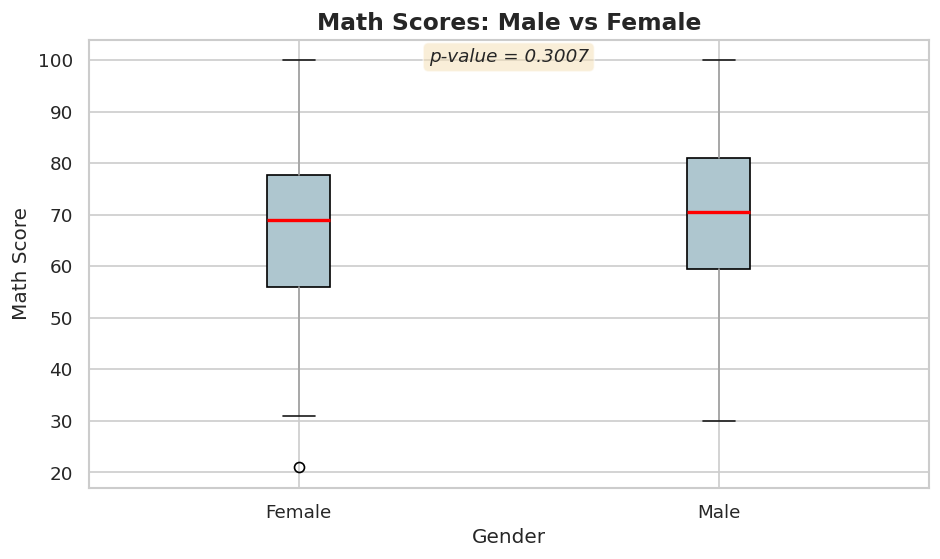

In [94]:
fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column="MathScore", by="Gender", ax=ax, patch_artist=True,
           boxprops=dict(facecolor="#AEC6CF"), medianprops=dict(color="red", linewidth=2))
ax.set_title("Math Scores: Male vs Female", fontsize=14, fontweight="bold")
ax.set_xlabel("Gender")
ax.set_ylabel("Math Score")
plt.suptitle("")
ax.text(0.5, 0.95, f"p-value = {p_value:.4f}", transform=ax.transAxes,
        ha="center", fontsize=11, style="italic", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
plt.tight_layout()
plt.show()

---
# SECTION 4: Correlation & Regression (5 Marks)

### Step 1: Correlation Matrix
Correlation ranges from -1 to +1. Above 0.7 = strong relationship.

In [95]:
corr_matrix = df[score_cols].corr()
print(corr_matrix)

              MathScore  ReadingScore  WritingScore
MathScore      1.000000      0.772049      0.770410
ReadingScore   0.772049      1.000000      0.818723
WritingScore   0.770410      0.818723      1.000000


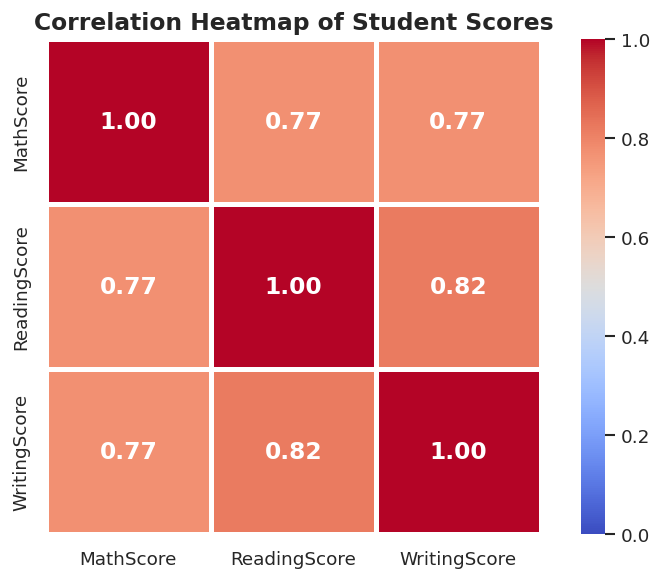

In [96]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=0, vmax=1, center=0.5, linewidths=2, linecolor="white",
            square=True, ax=ax, annot_kws={"size": 14, "weight": "bold"})
ax.set_title("Correlation Heatmap of Student Scores", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Step 2: Simple Linear Regression
Predict MathScore from ReadingScore: **y = mx + b**

In [97]:
slope, intercept = np.polyfit(df["ReadingScore"], df["MathScore"], 1)
correlation = df["ReadingScore"].corr(df["MathScore"])
r_squared = correlation ** 2

print(f"Equation: MathScore = {slope:.2f} x ReadingScore + {intercept:.2f}")
print(f"Slope     = {slope:.2f}")
print(f"Intercept = {intercept:.2f}")
print(f"R-squared = {r_squared:.4f} ({r_squared*100:.1f}% of Math variation explained by Reading)")

Equation: MathScore = 0.85 x ReadingScore + 8.44
Slope     = 0.85
Intercept = 8.44
R-squared = 0.5961 (59.6% of Math variation explained by Reading)


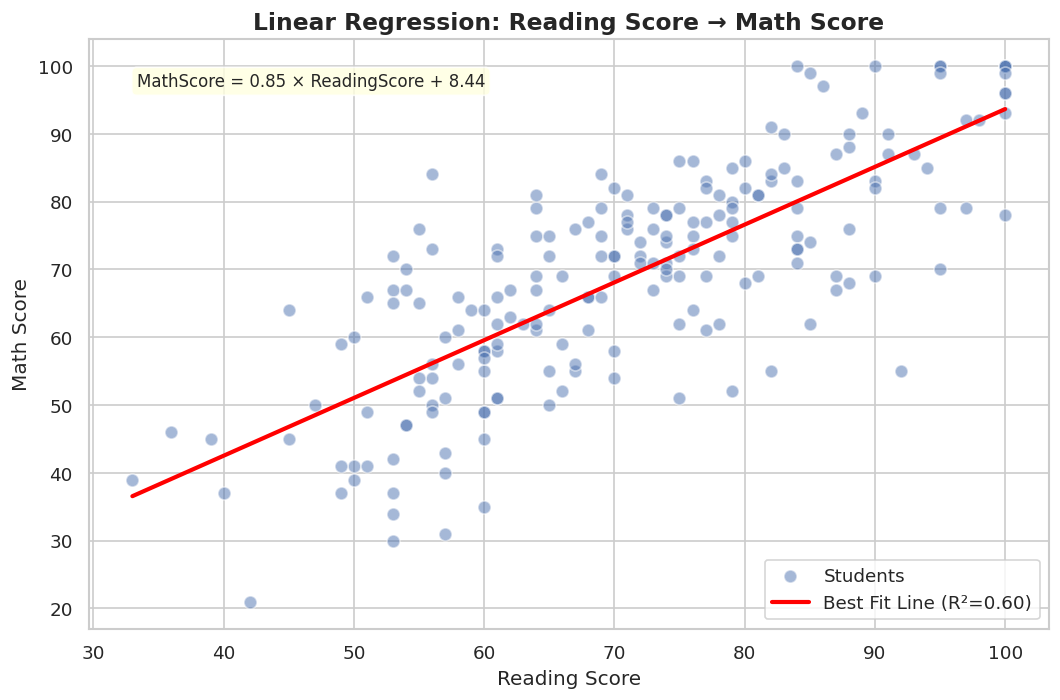

In [98]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df["ReadingScore"], df["MathScore"], alpha=0.5, color="#4C72B0", edgecolors="white", s=60, label="Students")

x_line = np.linspace(df["ReadingScore"].min(), df["ReadingScore"].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="red", linewidth=2.5, label=f"Best Fit Line (R²={r_squared:.2f})")

ax.set_title("Linear Regression: Reading Score → Math Score", fontsize=14, fontweight="bold")
ax.set_xlabel("Reading Score", fontsize=12)
ax.set_ylabel("Math Score", fontsize=12)
ax.legend(fontsize=11)
eq_text = f"MathScore = {slope:.2f} × ReadingScore + {intercept:.2f}"
ax.text(0.05, 0.92, eq_text, transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
plt.tight_layout()
plt.show()

---
# Project Summary

| # | Finding | Result |
|---|---------|--------|
| 1 | Average Scores | Math≈68.8, Reading≈70.8, Writing≈70.2 |
| 2 | Test Preparation | Students who prepared scored 5-8 pts higher |
| 3 | Bayes' Theorem | P(Prep\|HighMath) > P(Prep) — prep predicts success |
| 4 | CLT Verification | Sample means form normal distribution ✓ |
| 5 | 95% Confidence Interval | Math: ~[66.5, 71.1] |
| 6 | Gender Difference | NOT significant (p-value = 0.3007) |
| 7 | Correlation | All subjects strongly correlated (r = 0.77–0.82) |
| 8 | Regression | MathScore = 0.85 × ReadingScore + 8.44 (R² = 0.60) |

**Conclusion:** Test preparation significantly improves performance. There is no gender gap in Math. All subjects are strongly interconnected, and CLT confirms that sample means follow a normal distribution.